imports 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports OK")

Imports OK


chargements des données

In [3]:
from pathlib import Path


def find_data_raw_root():
    current = Path.cwd()
    for _ in range(4):
        candidate = current / "data" / "raw"
        if candidate.exists():
            return candidate
        current = current.parent
    raise FileNotFoundError("Impossible de trouver le dossier data/raw depuis le répertoire courant.")

DATA_DIR = find_data_raw_root()

train = pd.read_csv(DATA_DIR / "train(2).csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test_public.csv")

print("DATA_DIR :", DATA_DIR)
print("Train :", train.shape)
print("Validation :", validation.shape)
print("Test :", test.shape)

DATA_DIR : c:\Users\delim\OneDrive\Bureau\ML CHALLENGE\data\raw
Train : (180371, 43)
Validation : (38651, 43)
Test : (38651, 43)


colonne cible

In [4]:
train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,Label
0,0.022895,tcp,-,FIN,40,42,2542,23508,3537.890234,31,29,8.662153e+05,8.018868e+06,7,14,0.579179,0.544829,44.056135,42.327502,255,1414756534,1437253270,255,0.000664,0.000553,0.000111,64,560,0,0,9,0,4,1,1,4,0,0,0,5,11,0,0
1,0.004540,udp,-,CON,4,4,568,304,1541.850183,31,29,7.506608e+05,4.017621e+05,0,0,1.207333,1.039667,1.698237,1.458997,0,0,0,0,0.000000,0.000000,0.000000,142,76,0,0,3,0,11,1,1,3,0,0,0,4,7,0,0
2,0.761113,tcp,http,FIN,10,20,812,15532,38.102096,62,252,7.683485e+03,1.550992e+05,2,7,84.568111,35.120789,5525.583569,3202.326839,255,1687459506,2406905239,255,0.141273,0.093232,0.048041,81,777,0,0,1,1,1,1,1,1,0,0,0,1,1,0,2
3,0.000003,emcon,-,INT,2,0,180,0,333333.321500,254,0,2.400000e+08,0.000000e+00,0,0,0.003000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,90,0,0,0,10,2,11,10,10,10,0,0,0,10,10,0,2
4,0.000008,udp,dns,INT,2,0,114,0,125000.000300,254,0,5.700000e+07,0.000000e+00,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,27,2,16,16,16,28,0,0,0,17,27,0,1


info generale

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180371 entries, 0 to 180370
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                180371 non-null  float64
 1   proto              180371 non-null  object 
 2   service            180371 non-null  object 
 3   state              180371 non-null  object 
 4   spkts              180371 non-null  int64  
 5   dpkts              180371 non-null  int64  
 6   sbytes             180371 non-null  int64  
 7   dbytes             180371 non-null  int64  
 8   rate               180371 non-null  float64
 9   sttl               180371 non-null  int64  
 10  dttl               180371 non-null  int64  
 11  sload              180371 non-null  float64
 12  dload              180371 non-null  float64
 13  sloss              180371 non-null  int64  
 14  dloss              180371 non-null  int64  
 15  sinpkt             180371 non-null  float64
 16  di

vérification des colonnes

In [6]:
print("Train :", train.columns.tolist())

Train : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'Label']


Vérification cohérence Train / Validation / Test

In [7]:
train_cols = set(train.columns)
valid_cols = set(validation.columns)
test_cols = set(test.columns)

print("Train = Validation :", train_cols == valid_cols)
print("Train = Test :", train_cols == test_cols)

Train = Validation : True
Train = Test : False


Valeurs manquantes

In [8]:
missing = train.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

Series([], dtype: int64)


In [9]:
print(
    f"Total valeurs manquantes : {train.isnull().sum().sum()}"
)

Total valeurs manquantes : 0


Doublons

In [10]:
duplicates = train.duplicated().sum()

print(f"Doublons : {duplicates}")

Doublons : 61522


Description statistique

In [11]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
dur,180371.0,1.259370e+00,6.031214e+00,0.0,0.000008,0.004342,6.872365e-01,5.999999e+01
spkts,180371.0,1.976085e+01,1.374158e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,180371.0,1.868807e+01,1.174605e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,180371.0,8.512775e+03,1.755446e+05,24.0,114.000000,528.000000,1.356000e+03,1.435577e+07
dbytes,180371.0,1.463912e+04,1.537443e+05,0.0,0.000000,178.000000,1.070000e+03,1.465753e+07
rate,180371.0,9.108393e+04,1.599175e+05,0.0,30.782919,2952.755752,1.250000e+05,1.000000e+06
sttl,180371.0,1.799658e+02,1.024769e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,180371.0,8.504541e+01,1.128780e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,180371.0,7.053927e+07,1.851258e+08,0.0,12305.468260,739422.875000,8.000000e+07,5.600000e+09
dload,180371.0,6.581049e+05,2.412133e+06,0.0,0.000000,1777.832397,2.225204e+04,2.242273e+07


Distribution de la cible 

In [12]:
train["Label"].value_counts()

Label
0    65100
1    41209
2    31167
3    16972
4    11447
5     9791
6     1874
7     1631
8     1058
9      122
Name: count, dtype: int64

In [13]:
(
    train["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

Label
0    36.092276
1    22.846799
2    17.279385
3     9.409495
4     6.346364
5     5.428256
6     1.038970
7     0.904247
8     0.586569
9     0.067638
Name: proportion, dtype: float64

Visualisation des classes

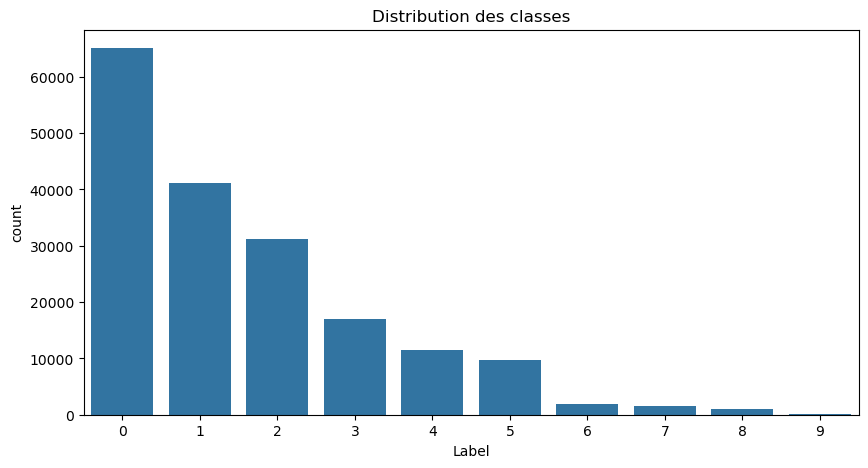

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="Label"
)

plt.title("Distribution des classes")
plt.show()

colonnes catégorielles 

In [15]:
categorical_cols = train.select_dtypes(
    include="object"
).columns

print(categorical_cols)

Index(['proto', 'service', 'state'], dtype='object')


Cardinalité

In [16]:
for col in categorical_cols:
    print("=" * 50)
    print(col)
    print("Valeurs uniques :", train[col].nunique())

proto
Valeurs uniques : 132
service
Valeurs uniques : 13
state
Valeurs uniques : 9


Analyse des variables numériques 

In [17]:
numeric_cols = train.select_dtypes(
    include=["int64", "float64"]
).columns

print(
    f"Variables numériques : {len(numeric_cols)}"
)

Variables numériques : 40


Colonnes constantes 

In [18]:
constant_cols = [
    col
    for col in train.columns
    if train[col].nunique() == 1
]

print(constant_cols)

[]


Distribution des classes 

In [19]:
train["Label"].value_counts().sort_index()

Label
0    65100
1    41209
2    31167
3    16972
4    11447
5     9791
6     1874
7     1631
8     1058
9      122
Name: count, dtype: int64

Nombres de modalités

In [20]:
for col in ["proto", "service", "state"]:
    print(f"\n{col}")
    print(train[col].nunique())


proto
132

service
13

state
9


Doublons par classe 

In [21]:
duplicates = train[train.duplicated()]

duplicates["Label"].value_counts().sort_index()

Label
0     4226
1    34321
2    10865
3     1864
4     7067
5     2571
6      349
7      225
8       33
9        1
Name: count, dtype: int64